# Batch Normalization in Deep Learning

### 1. Core Concept & Definition

Batch Normalization (BN) is an algorithmic optimization technique introduced in 2015 to stabilize and accelerate deep neural network training. It normalizes the linear activations ($z$) of hidden layers to maintain a mean of 0 and a standard deviation of 1 for every mini-batch.

* **Primary Purpose:** Achieves faster convergence in fewer training epochs and reduces network instability.
* **Mechanism:** Applied per-layer, per-neuron, and per-mini-batch during mini-batch gradient descent.

---

### 2. Theoretical Motivation & Mechanics

#### A. Faster Convergence via Symmetric Loss Contours

* **Unnormalized Data:** Creates elongated, asymmetrical cost function contours. Gradient descent is forced to use very small learning rates to avoid overshooting or divergence.
* **Normalized Data:** Formulates symmetric cost function contours. This enables the use of higher learning rates, accelerating convergence without instability.
* **Hidden Layer Analogy:** Just as input features $X$ are normalized to improve optimization, BN normalizes hidden layer activations because they serve as input features for subsequent layers.

#### B. Mitigating Internal Covariate Shift (ICS)

* **Covariate Shift:** A change in the input data distribution that requires model retraining, even if the underlying mapping function remains unchanged.
* **Internal Covariate Shift (ICS):** As weights update across layers during backpropagation, the activation distributions fed into deeper layers constantly shift.
* **BN Solution:** Fixes the mean and variance of layer activations across mini-batches, providing deeper layers with a consistent, stable input distribution to learn from.

---

### 3. Mathematical Workflow

During training with a mini-batch $B$ of size $m$:

1. **Calculate Mini-Batch Statistics:**
* Mean: $\mu_B = \frac{1}{m} \sum_{i=1}^{m} z^{(i)}$
  
* Variance: $\sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (z^{(i)} - \mu_B)^2$


2. **Standardize (Zero-Mean, Unit-Variance):**
* $\hat{z}^{(i)} = \frac{z^{(i)} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$ *(where $\epsilon$ is a tiny constant, typically $10^{-5}$, to prevent division by zero)*


3. **Scale and Shift (Learnable Parameters):**
* $z_{\text{BN}}^{(i)} = \gamma \hat{z}^{(i)} + \beta$
* $\gamma$ (scale factor) and $\beta$ (shift factor) are learnable parameters updated via backpropagation.
* **Why Scale & Shift?** If strictly enforcing zero mean and unit variance limits the layer's expressiveness (e.g., squashing inputs into non-linear activation regions like Sigmoid), the model can learn optimal values for $\gamma$ and $\beta$ to recover or adapt the representation power.



---

### 4. Training vs. Inference (Testing) Dynamics

During inference, inputs arrive individually or in batch sizes too small to calculate meaningful mini-batch statistics ($\mu_B, \sigma_B^2$).

* **Population Estimation:** BN tracks an **Exponentially Weighted Moving Average (EWMA)** of the batch means and variances calculated during training.
* **Inference Formula:** Evaluated using static running statistics ($\mu_{\text{EWMA}}$ and $\sigma^2_{\text{EWMA}}$) instead of mini-batch calculations.

#### Parameter Count Per BN Neuron

Every neuron applying Batch Normalization tracks **4 parameters**:

| Parameter Type | Parameters | Function |
| --- | --- | --- |
| **Trainable** | $\gamma, \beta$ | Learned during backpropagation to scale and shift activations |
| **Non-Trainable** | $\mu_{\text{EWMA}}, \sigma^2_{\text{EWMA}}$ | Updated via moving averages for execution during inference |

---

### 5. Key Advantages

* **Higher Learning Rates:** Smoothes the loss landscape, preventing gradient explosion/vanishing and enabling faster optimization.
* **Reduced Initial Weight Sensitivity:** Makes training less dependent on precise initial weight distributions.
* **Mild Regularization:** The stochastic noise introduced by mini-batch statistics acts as a weak regularizer, reducing reliance on Dropout (though not completely replacing it).

---

### 6. Implementation Reference (Keras)

Batch Normalization is integrated as a structural layer placed immediately after the linear projection (`Dense`) and before or after the activation function depending on architecture design:

```python
import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization, Dense
from tensorflow.keras.models import Sequential

model = Sequential(
    [
        # Hidden Layer 1
        Dense(units=64, input_dim=20),
        BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        # Hidden Layer 2
        Dense(units=32),
        BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        # Output Layer
        Dense(units=1, activation="sigmoid"),
    ]
)

model.summary()

```

In [1]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 

import tensorflow 
from tensorflow.keras.layers import Dense , Input , BatchNormalization 
from tensorflow.keras import Sequential

In [2]:
df = pd.read_csv('datasets/concertriccir2.csv')

df.head()

,7.003345706103683010e-01,-2.470675778972781789e-01,0.000000000000000000e+00
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0
3,2.560483,-1.846577,1.0
4,-1.724979,3.463930,1.0


In [5]:
df.columns = ['X', 'Y', 'Class'] 

df.head()

,X,Y,Class
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0
3,2.560483,-1.846577,1.0
4,-1.724979,3.463930,1.0


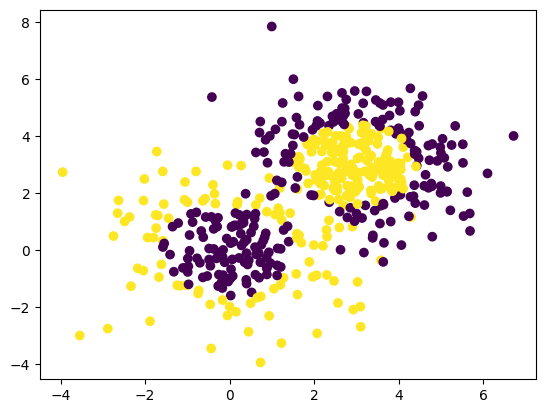

In [8]:
plt.scatter(df['X'],df['Y'],c=df['Class']) ;

In [9]:
x = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

# Without Batch Normalization 

In [12]:
model = Sequential([
    Input(shape=(2,)), 
    Dense(2,activation='relu'), 
    Dense(2,activation='relu'), 
    Dense(1,activation='sigmoid')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    loss = 'binary_crossentropy', 
    optimizer = 'adam' , 
    metrics = ['accuracy']
)

In [14]:
hist1 = model.fit(x,
                 y,
                 epochs= 200,
                 validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.5388 - loss: 0.6878 - val_accuracy: 0.5400 - val_loss: 0.7300
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5514 - loss: 0.6860 - val_accuracy: 0.5500 - val_loss: 0.7288
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5614 - loss: 0.6850 - val_accuracy: 0.5600 - val_loss: 0.7272
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5815 - loss: 0.6841 - val_accuracy: 0.5900 - val_loss: 0.7255
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5915 - loss: 0.6832 - val_accuracy: 0.6000 - val_loss: 0.7247
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5990 - loss: 0.6828 - val_accuracy: 0.6200 - val_loss: 0.7226
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6015 - loss: 0.6820 - val_accuracy: 0.6200 - val_loss: 0.7219
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5990 - loss: 0.6815 - val_accuracy: 0.

# With Batch Normalization 

In [16]:
model2 = Sequential([
    Input(shape=(2,)), 
    Dense(3,activation='relu'),
    BatchNormalization(),
    Dense(2,activation='relu'),
    BatchNormalization(),
    Dense(1,activation='sigmoid')
])

model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 3)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 3)                   │              12 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 2)                   │               8 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 2)                   │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [17]:
model2.compile(
    loss = 'binary_crossentropy', 
    optimizer = 'adam' , 
    metrics = ['accuracy']
)

In [18]:
hist2 = model2.fit(
                x,
                y,
                epochs= 200,
                validation_split=0.2
                    )

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.4286 - loss: 1.0243 - val_accuracy: 0.5700 - val_loss: 1.4394
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4837 - loss: 0.9302 - val_accuracy: 0.5700 - val_loss: 1.2905
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4612 - loss: 0.9170 - val_accuracy: 0.5600 - val_loss: 1.1853
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5063 - loss: 0.8493 - val_accuracy: 0.5600 - val_loss: 1.0988
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5038 - loss: 0.8351 - val_accuracy: 0.5300 - val_loss: 1.0275
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5063 - loss: 0.8175 - val_accuracy: 0.5300 - val_loss: 0.9696
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5013 - loss: 0.8204 - val_accuracy: 0.5000 - val_loss: 0.9221
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5163 - loss: 0.7977 - val_accuracy: 0.

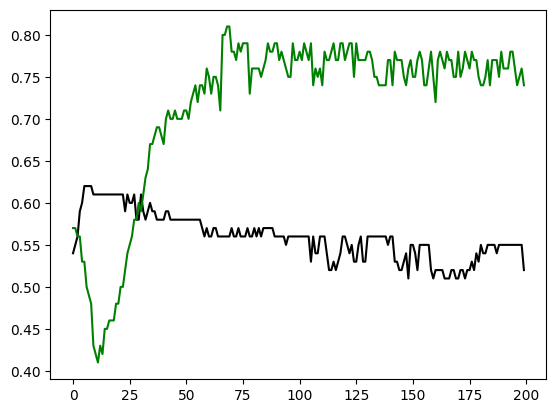

In [19]:
plt.plot(hist1.history['val_accuracy'],color='black')
plt.plot(hist2.history['val_accuracy'],color='green') # Batch Normalization 